<a href="https://colab.research.google.com/github/roasfora/project_rh/blob/main/projeto_rh_crispdm_visualizacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto guiado — CRISP-DM com Visualização (Recursos Humanos)

Projeto de RH para encontrar insights com `pandas`, `matplotlib` e `seaborn`.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Business Understanding
Pergunta de negócio: **Que padrões ajudam a explicar a saída de colaboradores?**

## 2. Data Understanding

In [ ]:
df = pd.read_csv('/content/rh_funcionarios.csv')
df.head()

,funcionario_id,departamento,cargo,idade,genero,anos_empresa,salario,modalidade,avaliacao_desempenho,saiu_empresa
0,1,Tecnologia,Analista,28,F,2,3200,Híbrido,4.2,Não
1,2,RH,Especialista,35,F,6,2800,Presencial,3.8,Não
2,3,Financeiro,Analista,31,M,4,3000,Híbrido,3.5,Sim
3,4,Tecnologia,Cientista de Dados,29,M,3,4200,Remoto,4.6,Não
4,5,Operações,Supervisor,41,F,10,3600,Presencial,3.2,Sim


In [ ]:
print(df.shape)
print(df.columns.tolist())

(20, 10)
['funcionario_id', 'departamento', 'cargo', 'idade', 'genero', 'anos_empresa', 'salario', 'modalidade', 'avaliacao_desempenho', 'saiu_empresa']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   funcionario_id        20 non-null     int64  
 1   departamento          20 non-null     object 
 2   cargo                 20 non-null     object 
 3   idade                 20 non-null     int64  
 4   genero                20 non-null     object 
 5   anos_empresa          20 non-null     int64  
 6   salario               20 non-null     int64  
 7   modalidade            20 non-null     object 
 8   avaliacao_desempenho  20 non-null     float64
 9   saiu_empresa          20 non-null     object 
dtypes: float64(1), int64(4), object(5)
memory usage: 1.7+ KB


In [ ]:
df.describe()

,funcionario_id,idade,anos_empresa,salario,avaliacao_desempenho
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,32.800000,5.200000,3600.000000,3.810000
std,5.91608,5.549775,3.473206,1026.491213,0.606022
min,1.00000,24.000000,1.000000,1800.000000,2.800000
25%,5.75000,28.750000,2.000000,2875.000000,3.275000
50%,10.50000,32.500000,4.500000,3450.000000,3.900000
75%,15.25000,37.250000,7.250000,4350.000000,4.325000
max,20.00000,42.000000,12.000000,5400.000000,4.700000


## 3. Data Preparation

In [ ]:
df["saiu_bin"] = df["saiu_empresa"].map({"Sim": 1, "Não": 0})
df["faixa_tempo_empresa"] = pd.cut(
    df["anos_empresa"],
    bins=[0, 2, 5, 10, 20],
    labels=["0-2", "3-5", "6-10", "11+"],
    include_lowest=True
)
df.head()

,funcionario_id,departamento,cargo,idade,genero,anos_empresa,salario,modalidade,avaliacao_desempenho,saiu_empresa,saiu_bin,faixa_tempo_empresa
0,1,Tecnologia,Analista,28,F,2,3200,Híbrido,4.2,Não,0,0-2
1,2,RH,Especialista,35,F,6,2800,Presencial,3.8,Não,0,6-10
2,3,Financeiro,Analista,31,M,4,3000,Híbrido,3.5,Sim,1,3-5
3,4,Tecnologia,Cientista de Dados,29,M,3,4200,Remoto,4.6,Não,0,3-5
4,5,Operações,Supervisor,41,F,10,3600,Presencial,3.2,Sim,1,6-10


## 4. Visualizações para entender os dados

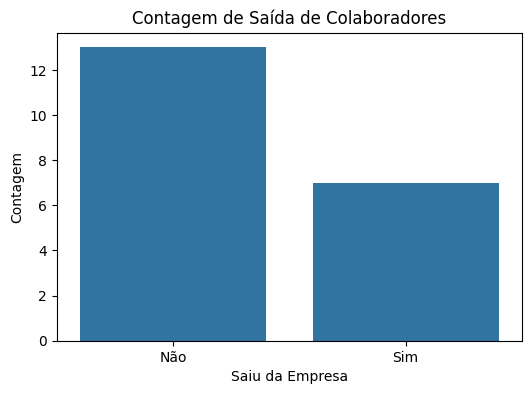

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="saiu_empresa")
plt.title("Contagem de Saída de Colaboradores")
plt.xlabel("Saiu da Empresa")
plt.ylabel("Contagem")
plt.show()

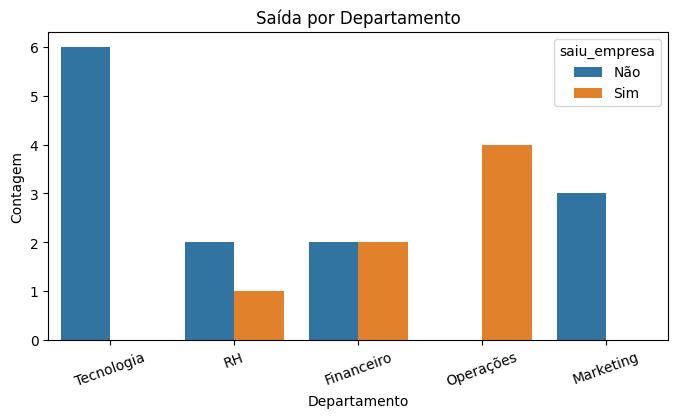

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="departamento", hue="saiu_empresa")
plt.title("Saída por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Contagem")
plt.xticks(rotation=20)
plt.show()

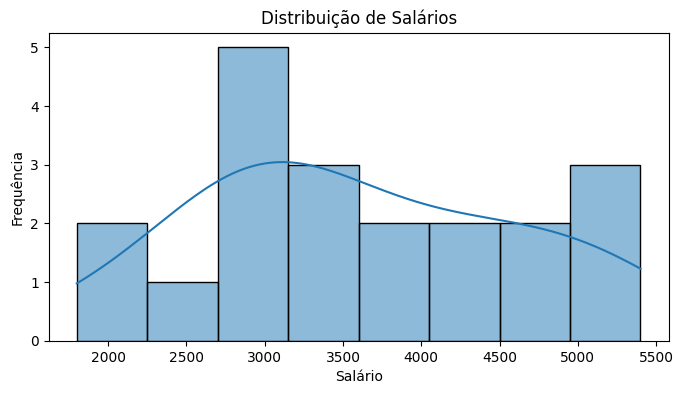

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="salario", bins=8, kde=True)
plt.title("Distribuição de Salários")
plt.xlabel("Salário")
plt.ylabel("Frequência")
plt.show()

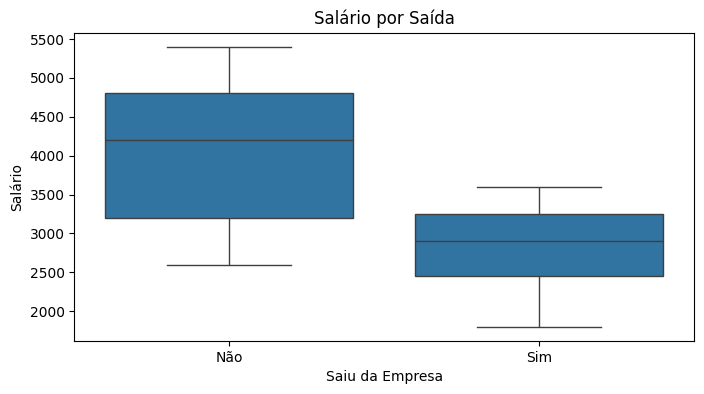

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="saiu_empresa", y="salario")
plt.title("Salário por Saída")
plt.xlabel("Saiu da Empresa")
plt.ylabel("Salário")
plt.show()

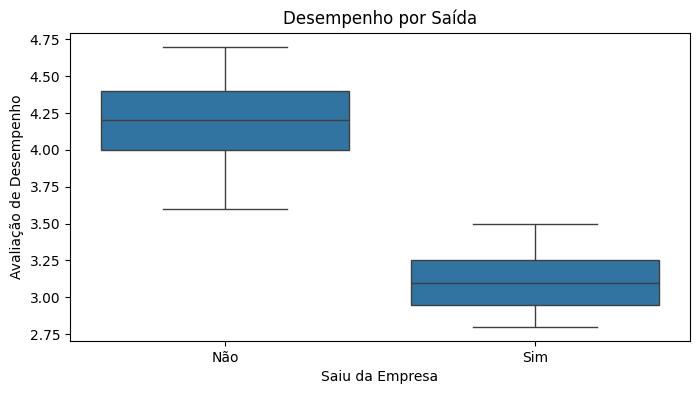

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="saiu_empresa", y="avaliacao_desempenho")
plt.title("Desempenho por Saída")
plt.xlabel("Saiu da Empresa")
plt.ylabel("Avaliação de Desempenho")
plt.show()

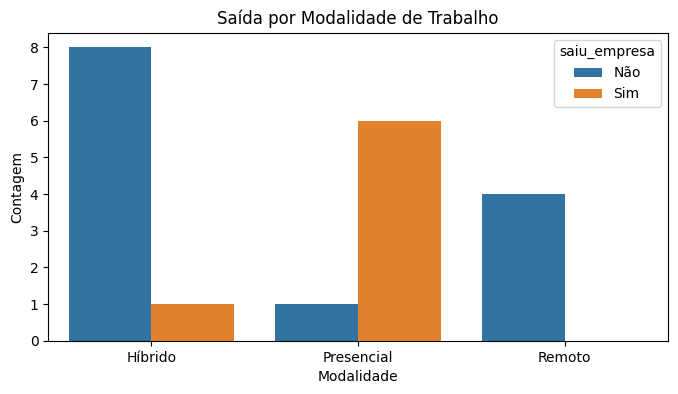

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="modalidade", hue="saiu_empresa")
plt.title("Saída por Modalidade de Trabalho")
plt.xlabel("Modalidade")
plt.ylabel("Contagem")
plt.show()

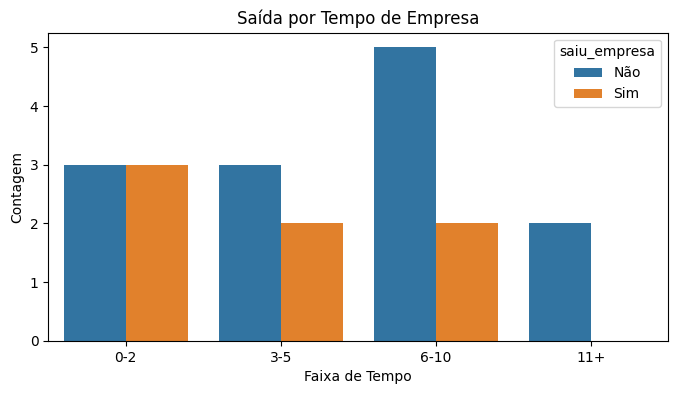

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="faixa_tempo_empresa", hue="saiu_empresa")
plt.title("Saída por Tempo de Empresa")
plt.xlabel("Faixa de Tempo")
plt.ylabel("Contagem")
plt.show()

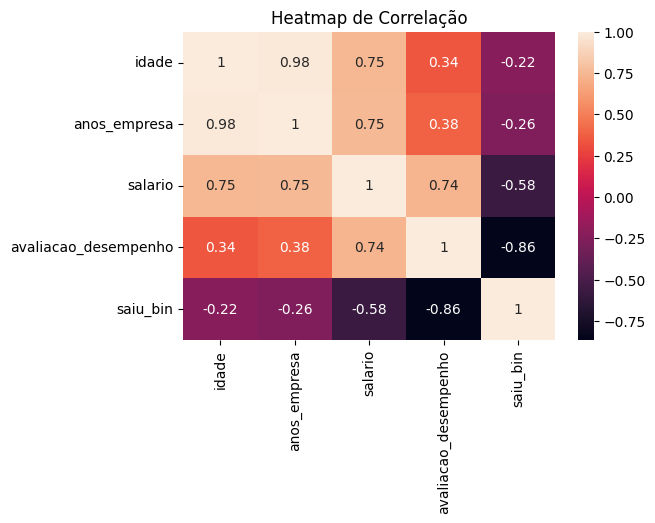

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["idade", "anos_empresa", "salario", "avaliacao_desempenho", "saiu_bin"]].corr(), annot=True)
plt.title("Heatmap de Correlação")
plt.show()

## 5. Analysis

In [ ]:
rotatividade_dep = df.groupby("departamento")["saiu_bin"].mean().reset_index().sort_values("saiu_bin", ascending=False)
rotatividade_dep

,departamento,saiu_bin
2,Operações,1.000000
0,Financeiro,0.500000
3,RH,0.333333
1,Marketing,0.000000
4,Tecnologia,0.000000


In [ ]:
rotatividade_modalidade = df.groupby("modalidade")["saiu_bin"].mean().reset_index().sort_values("saiu_bin", ascending=False)
rotatividade_modalidade

,modalidade,saiu_bin
1,Presencial,0.857143
0,Híbrido,0.111111
2,Remoto,0.000000


In [ ]:
rotatividade_tempo = df.groupby("faixa_tempo_empresa")["saiu_bin"].mean().reset_index()
rotatividade_tempo

/tmp/ipykernel_22295/650523184.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rotatividade_tempo = df.groupby("faixa_tempo_empresa")["saiu_bin"].mean().reset_index()


,faixa_tempo_empresa,saiu_bin
0,0-2,0.500000
1,3-5,0.400000
2,6-10,0.285714
3,11+,0.000000


## 6. Evaluation

In [ ]:
print("Departamento com maior rotatividade:", rotatividade_dep.iloc[0]["departamento"])
print("Modalidade com maior rotatividade:", rotatividade_modalidade.iloc[0]["modalidade"])

Departamento com maior rotatividade: Operações
Modalidade com maior rotatividade: Presencial


## 7. Deploy / Comunicação

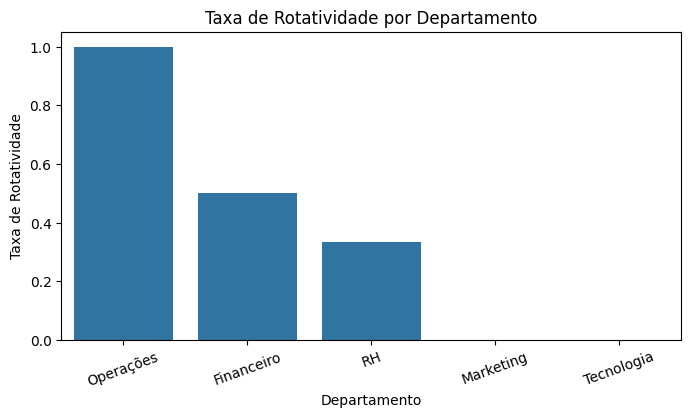

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(data=rotatividade_dep, x="departamento", y="saiu_bin")
plt.title("Taxa de Rotatividade por Departamento")
plt.xlabel("Departamento")
plt.ylabel("Taxa de Rotatividade")
plt.xticks(rotation=20)
plt.show()

## 8. Fecho
Este projeto mostra como visualizações ajudam a transformar dados de RH em insights de negócio.